# S&P 500 Gaussian-emission diagnostics

This notebook uses the saved development-run artifacts. It does not refit the HMM or require the experiment notebook's kernel. Set `RUN_DIRECTORY` to another completed run to inspect it.

The selected years are illustrative. Forecast comparisons use state probabilities saved before each return; individual hidden states are not observed.


In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
RUN_DIRECTORY = project_root / "data/artifacts/sp500/2026-10-02_20-30-34_648329_UTC"
manifest = json.loads((RUN_DIRECTORY / "manifest.json").read_text())
forecasts = pd.read_json(RUN_DIRECTORY / "forecasts.json", orient="records")
required = {"date", "year", "r_t", "pit", "predicted_state", "emission_means", "emission_variances", "quantiles"}
missing = required - set(forecasts.columns)
if missing:
    raise ValueError(f"Forecast artifact is missing columns: {sorted(missing)}")
forecasts["date"] = pd.to_datetime(forecasts["date"], utc=True)
forecasts = forecasts.set_index("date").sort_index()
run_id = manifest["run_id"]
run_directory = RUN_DIRECTORY
print(f"Loaded {len(forecasts):,} forecasts from development run {run_id}")


Loaded 6,553 forecasts from development run cdf24bec574ed846


## 1. Selected-year return distributions and Gaussian-emission diagnostics

Compare illustrative development years (1990, 2001, 2008, 2015) with the average of their one-step predictive mixtures. Solid curves use probabilities available before each return; dashed curves are the fitted Gaussian component contributions, ordered by volatility. No observed state labels are assumed.

PIT distance from uniform and the area between empirical and predictive return CDFs measure forecast departure (zero is ideal). Tail counts and interval coverage show where it occurs. These are descriptive diagnostics, not p-values or a direct test of each state's Gaussianity.


,days,PIT_KS_distance,CDF_area_distance_pp,1pct_tail_violations,1pct_expected,5pct_tail_violations,5pct_expected,90pct_coverage,95pct_coverage
year,,,,,,,,,
1990,253,0.0791,0.1184,5,2.53,17,12.65,0.8854,0.9368
2001,248,0.0661,0.1137,4,2.48,20,12.40,0.8750,0.9395
2008,253,0.0959,0.5742,17,2.53,33,12.65,0.7589,0.8379
2015,252,0.0645,0.1094,5,2.52,19,12.60,0.8968,0.9603


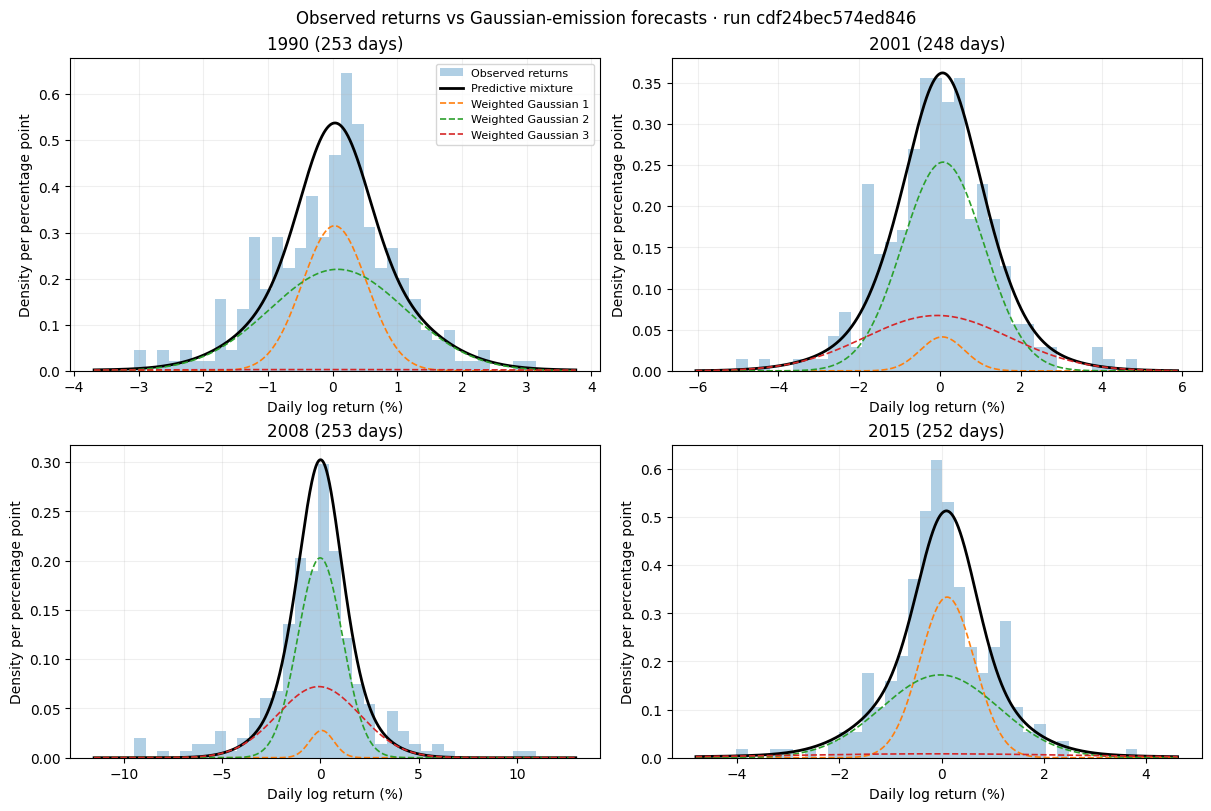

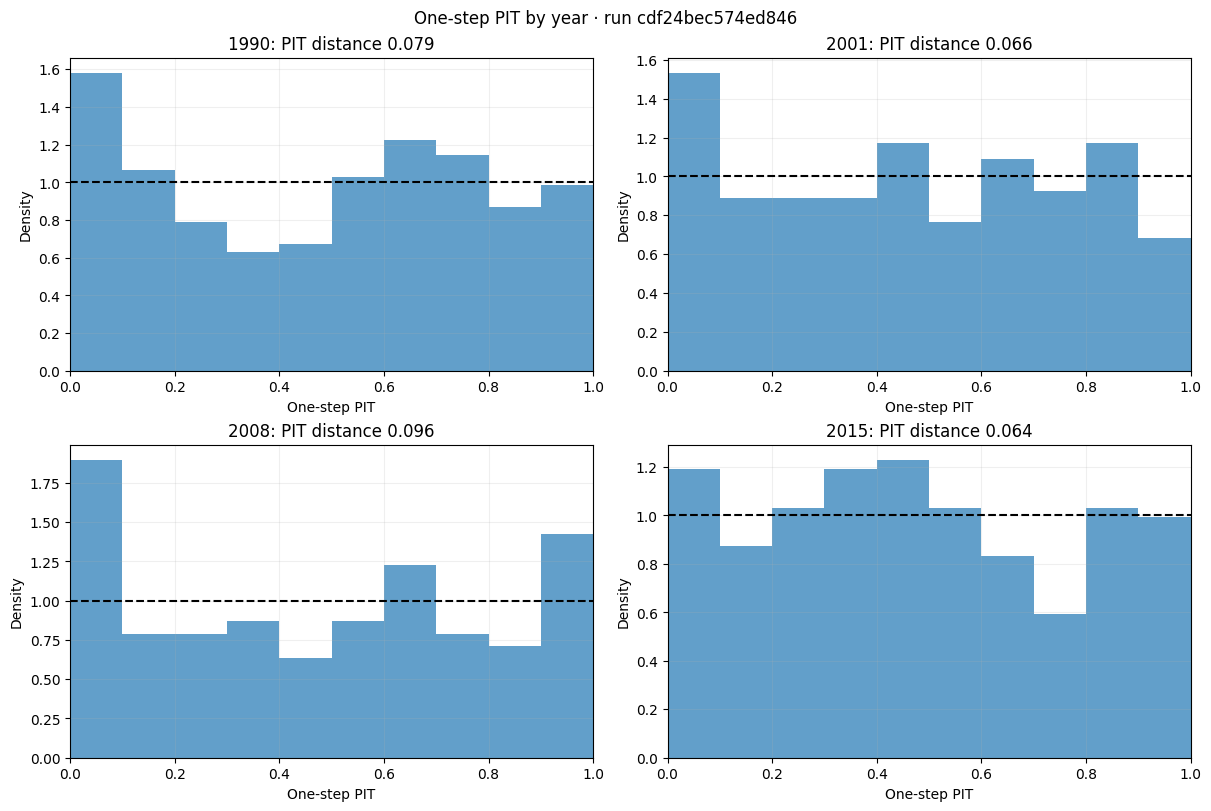

In [12]:
from math import erf, sqrt

YEARS_TO_PLOT = (1990, 2001, 2008, 2015)
selected_years = [year for year in YEARS_TO_PLOT if year in forecasts.year.unique()]
assert selected_years, "No selected year is in the development forecasts."
density_figure, density_axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
pit_figure, pit_axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
distribution_rows = []

for year, density_axis, pit_axis in zip(selected_years, density_axes.flat, pit_axes.flat):
    group = forecasts.loc[forecasts.year == year].sort_index()
    realized = group.r_t.to_numpy()
    means = np.asarray(group.emission_means.iloc[0], dtype=float)
    deviations = np.sqrt(np.asarray(group.emission_variances.iloc[0], dtype=float))
    average_weights = np.stack(group.predicted_state.to_numpy()).mean(axis=0)
    margin = 0.1 * (realized.max() - realized.min())
    grid = np.linspace(realized.min() - margin, realized.max() + margin, 1200)
    components = np.exp(-0.5 * ((grid[:, None] - means) / deviations) ** 2) / (np.sqrt(2 * np.pi) * deviations)
    density_axis.hist(realized * 100, bins=35, density=True, alpha=0.35, label="Observed returns")
    density_axis.plot(grid * 100, components @ average_weights / 100, color="black", linewidth=2, label="Predictive mixture")
    for rank, state in enumerate(np.argsort(deviations), start=1):
        density_axis.plot(grid * 100, average_weights[state] * components[:, state] / 100,
                          linestyle="--", linewidth=1.2, label=f"Weighted Gaussian {rank}")
    density_axis.set(title=f"{year} ({len(group)} days)", xlabel="Daily log return (%)", ylabel="Density per percentage point")
    density_axis.grid(alpha=0.2)

    pit = np.sort(group.pit.to_numpy())
    count = len(pit)
    steps = np.arange(1, count + 1) / count
    pit_distance = max(np.max(steps - pit), np.max(pit - (steps - 1 / count)))
    pit_axis.hist(pit, bins=np.linspace(0, 1, 11), density=True, alpha=0.7)
    pit_axis.axhline(1, color="black", linestyle="--")
    pit_axis.set(title=f"{year}: PIT distance {pit_distance:.3f}", xlabel="One-step PIT", ylabel="Density", xlim=(0, 1))
    pit_axis.grid(alpha=0.2)

    integration_grid = np.linspace(min(realized.min(), np.min(means - 8 * deviations)),
                                   max(realized.max(), np.max(means + 8 * deviations)), 1200)
    component_cdfs = np.column_stack([
        [0.5 * (1 + erf((value - mean) / (sqrt(2) * deviation))) for value in integration_grid]
        for mean, deviation in zip(means, deviations)
    ])
    predictive_cdf = component_cdfs @ average_weights
    empirical_cdf = np.searchsorted(np.sort(realized), integration_grid, side="right") / count
    quantiles = group.quantiles.to_list()
    lower_1 = np.array([item["0.01"] for item in quantiles])
    lower_5 = np.array([item["0.05"] for item in quantiles])
    upper_95 = np.array([item["0.95"] for item in quantiles])
    lower_025 = np.array([item["0.025"] for item in quantiles])
    upper_975 = np.array([item["0.975"] for item in quantiles])
    distribution_rows.append({
        "year": year, "days": count, "PIT_KS_distance": pit_distance,
        "CDF_area_distance_pp": 100 * np.trapezoid(np.abs(empirical_cdf - predictive_cdf), integration_grid),
        "1pct_tail_violations": int(np.sum(realized < lower_1)), "1pct_expected": 0.01 * count,
        "5pct_tail_violations": int(np.sum(realized < lower_5)), "5pct_expected": 0.05 * count,
        "90pct_coverage": np.mean((realized >= lower_5) & (realized <= upper_95)),
        "95pct_coverage": np.mean((realized >= lower_025) & (realized <= upper_975)),
    })

for axis in list(density_axes.flat)[len(selected_years):] + list(pit_axes.flat)[len(selected_years):]:
    axis.set_visible(False)
density_axes.flat[0].legend(fontsize=8)
density_figure.suptitle(f"Observed returns vs Gaussian-emission forecasts · run {run_id}")
pit_figure.suptitle(f"One-step PIT by year · run {run_id}")
distribution_diagnostics = pd.DataFrame(distribution_rows).set_index("year")
display(distribution_diagnostics.round(4))
density_figure.savefig(run_directory / "selected_year_return_densities.png", dpi=160)
pit_figure.savefig(run_directory / "selected_year_pit.png", dpi=160)
distribution_diagnostics.to_csv(run_directory / "selected_year_distribution_diagnostics.csv")
plt.show()

## 2. Log returns and all-year distance summary

The following table is computed from `forecasts.json` for every evaluation year in the selected run. Smaller distances indicate closer predictive calibration. `PIT_KS_distance` is the maximum departure of the one-step PIT empirical CDF from uniform; `CDF_area_distance_pp` is the integrated absolute gap between the empirical return CDF and the year's average one-step predictive CDF, in percentage points of daily return. The annual mean and **sample variance** describe variation across years; top-five lists rank the largest departures separately for each metric. These are descriptive measures of the predictive mixture, not direct tests of Gaussianity within an unobserved state.


In [13]:
from math import erf, sqrt

annual_distance_rows = []
for year, group in forecasts.groupby("year", sort=True):
    realized = group.r_t.to_numpy(dtype=float)
    means = np.asarray(group.emission_means.iloc[0], dtype=float)
    deviations = np.sqrt(np.asarray(group.emission_variances.iloc[0], dtype=float))
    average_weights = np.stack(group.predicted_state.to_numpy()).mean(axis=0)
    grid = np.linspace(min(realized.min(), np.min(means - 8 * deviations)),
                       max(realized.max(), np.max(means + 8 * deviations)), 1200)
    component_cdfs = np.column_stack([
        [0.5 * (1 + erf((value - mean) / (sqrt(2) * deviation))) for value in grid]
        for mean, deviation in zip(means, deviations)
    ])
    predictive_cdf = component_cdfs @ average_weights
    empirical_cdf = np.searchsorted(np.sort(realized), grid, side="right") / len(realized)
    pit = np.sort(group.pit.to_numpy(dtype=float))
    steps = np.arange(1, len(pit) + 1) / len(pit)
    annual_distance_rows.append({
        "year": int(year),
        "days": len(group),
        "PIT_KS_distance": max(np.max(steps - pit), np.max(pit - (steps - 1 / len(pit)))),
        "CDF_area_distance_pp": 100 * np.trapezoid(np.abs(empirical_cdf - predictive_cdf), grid),
    })

annual_distances = pd.DataFrame(annual_distance_rows).set_index("year")
distance_columns = ["PIT_KS_distance", "CDF_area_distance_pp"]
distance_summary = annual_distances[distance_columns].agg(["mean", "var"])
distance_summary.index = ["mean", "sample variance"]
pit_largest = annual_distances.nlargest(5, "PIT_KS_distance").reset_index()
cdf_largest = annual_distances.nlargest(5, "CDF_area_distance_pp").reset_index()
top_five = pd.DataFrame({
    "PIT_year": pit_largest.year,
    "PIT_KS_distance": pit_largest.PIT_KS_distance,
    "CDF_year": cdf_largest.year,
    "CDF_area_distance_pp": cdf_largest.CDF_area_distance_pp,
})
top_five.index = np.arange(1, 6)
top_five.index.name = "rank"
print(f"All evaluation years · run {run_id}")
display(annual_distances.round(4))
print("Across-year summary")
display(distance_summary.round(6))
print("Five largest departures by metric")
display(top_five.round(4))
annual_distances.to_csv(run_directory / "all_year_distribution_distances.csv")
distance_summary.to_csv(run_directory / "all_year_distribution_summary.csv")
top_five.to_csv(run_directory / "all_year_distribution_top_five.csv")

All evaluation years · run cdf24bec574ed846


,days,PIT_KS_distance,CDF_area_distance_pp
year,,,
1990,253,0.0791,0.1184
1991,253,0.0506,0.0726
1992,254,0.1080,0.2110
1993,253,0.1149,0.2409
1994,252,0.0995,0.1499
1995,252,0.1499,0.2284
1996,254,0.0585,0.0745
1997,253,0.0728,0.1137
1998,252,0.0787,0.1997


Across-year summary


,PIT_KS_distance,CDF_area_distance_pp
mean,0.081208,0.153614
sample variance,0.000596,0.010089


Five largest departures by metric


,PIT_year,PIT_KS_distance,CDF_year,CDF_area_distance_pp
rank,,,,
1,1995,0.1499,2008,0.5742
2,1993,0.1149,1993,0.2409
3,1992,0.1080,2002,0.2334
4,2010,0.1064,1995,0.2284
5,2009,0.1051,1992,0.2110


## 3. Year-by-year predictive distribution test

For a return value `r`, each dashed curve is `average_state_probability[k] × GaussianPDF(r; mean[k], variance[k])`. The black curve is their **sum**. Because all terms are nonnegative, its peak can exceed any individual dashed curve. A broad state with a small average probability may appear nearly flat on the plotted range.

The test below assesses the **one-step predictive mixture**, not each hidden state's emission separately. Under a correctly specified conditional forecast, the PIT values should be independent Uniform(0, 1). For each evaluation year, compare the observed PIT KS distance with 10,000 simulated uniform samples of the same length. The KS statistic checks marginal uniformity; it does not separately test serial independence. Holm-adjusted p-values account for testing all years; `reject_at_5pct` flags adjusted p-values below 0.05. This Monte Carlo reference treats fitted parameters as fixed and does not include training uncertainty. Failure to reject is not proof that the Gaussian emissions are correct. A normality test on the raw yearly returns would test the wrong null, because a mixture of Gaussian emissions need not be Gaussian.


In [14]:
NULL_SAMPLES = 10_000
TEST_SEED = 20261002
test_rng = np.random.default_rng(TEST_SEED)
null_distances = {}
test_rows = []

for year, group in forecasts.groupby("year", sort=True):
    pit = np.sort(group.pit.to_numpy(dtype=float))
    days = len(pit)
    upper_steps = np.arange(1, days + 1) / days
    lower_steps = np.arange(days) / days
    observed_distance = max(np.max(upper_steps - pit), np.max(pit - lower_steps))
    if days not in null_distances:
        simulated = test_rng.random((NULL_SAMPLES, days))
        simulated.sort(axis=1)
        null_distances[days] = np.maximum(
            np.max(upper_steps - simulated, axis=1),
            np.max(simulated - lower_steps, axis=1),
        )
    p_value = (1 + np.count_nonzero(null_distances[days] >= observed_distance)) / (NULL_SAMPLES + 1)
    test_rows.append({"year": int(year), "days": days,
                      "PIT_KS_distance": observed_distance, "MC_p_value": p_value})

pit_tests = pd.DataFrame(test_rows).set_index("year")
p_values = pit_tests.MC_p_value.to_numpy()
order = np.argsort(p_values)
adjusted = np.empty(len(p_values))
adjusted[order] = np.minimum(1, np.maximum.accumulate(
    (len(p_values) - np.arange(len(p_values))) * p_values[order]
))
pit_tests["Holm_p_value"] = adjusted
pit_tests["reject_at_5pct"] = pit_tests.Holm_p_value < 0.05
np.testing.assert_allclose(pit_tests.PIT_KS_distance, annual_distances.PIT_KS_distance)
display(pit_tests.round(4))
print(f"Holm-adjusted rejections: {int(pit_tests.reject_at_5pct.sum())} of {len(pit_tests)} years")
pit_tests.to_csv(run_directory / "all_year_pit_ks_tests.csv")

,days,PIT_KS_distance,MC_p_value,Holm_p_value,reject_at_5pct
year,,,,,
1990,253,0.0791,0.0812,1.0000,False
1991,253,0.0506,0.5265,1.0000,False
1992,254,0.1080,0.0056,0.1344,False
1993,253,0.1149,0.0036,0.0900,False
1994,252,0.0995,0.0137,0.2740,False
1995,252,0.1499,0.0001,0.0026,True
1996,254,0.0585,0.3306,1.0000,False
1997,253,0.0728,0.1330,1.0000,False
1998,252,0.0787,0.0801,1.0000,False


Holm-adjusted rejections: 1 of 26 years


### Downside-tail tests

The omnibus KS test can have limited sensitivity to a small number of extreme losses. For each year, count PIT values below 0.01 and 0.05, then use a one-sided exact binomial test for **more** violations than expected. Holm adjustment is applied across all 52 year-by-threshold tail tests. These p-values share the fixed-forecast and parameter-uncertainty caveats above; they test predictive tail calibration, not a hidden state's Gaussianity.


In [15]:
from math import comb

tail_rows = []
for year, group in forecasts.groupby("year", sort=True):
    pit = group.pit.to_numpy(dtype=float)
    days = len(pit)
    for level in (0.01, 0.05):
        violations = int(np.count_nonzero(pit < level))
        upper_tail_probability = sum(
            comb(days, count) * level**count * (1 - level)**(days - count)
            for count in range(violations, days + 1)
        )
        tail_rows.append({
            "year": int(year), "threshold": level, "days": days,
            "observed": violations, "expected": days * level,
            "one_sided_p_value": upper_tail_probability,
        })

tail_tests = pd.DataFrame(tail_rows).set_index(["year", "threshold"])
tail_p_values = tail_tests.one_sided_p_value.to_numpy()
tail_order = np.argsort(tail_p_values)
tail_adjusted = np.empty(len(tail_p_values))
tail_adjusted[tail_order] = np.minimum(1, np.maximum.accumulate(
    (len(tail_p_values) - np.arange(len(tail_p_values))) * tail_p_values[tail_order]
))
tail_tests["Holm_p_value"] = tail_adjusted
tail_tests["reject_at_5pct"] = tail_tests.Holm_p_value < 0.05
display(tail_tests.round(6))
print(f"Holm-adjusted tail rejections: {int(tail_tests.reject_at_5pct.sum())} of {len(tail_tests)} tests")
tail_tests.to_csv(run_directory / "all_year_downside_tail_tests.csv")

days  observed  expected  one_sided_p_value  Holm_p_value  \
year threshold                                                              
1990 0.01        253         5      2.53           0.111859      1.000000   
     0.05        253        17     12.65           0.134687      1.000000   
1991 0.01        253         2      2.53           0.720352      1.000000   
     0.05        253         7     12.65           0.971287      1.000000   
1992 0.01        254         0      2.54           1.000000      1.000000   
     0.05        254         4     12.70           0.998908      1.000000   
1993 0.01        253         1      2.53           0.921349      1.000000   
     0.05        253         2     12.65           0.999967      1.000000   
1994 0.01        252         1      2.52           0.920555      1.000000   
     0.05        252        10     12.60           0.812957      1.000000   
1995 0.01        252         0      2.52           1.000000      1.000000   
     0.05        252         3     12.60           0.999752      1.000000   
1996 0.01        254         3      2.54           0.467096      1.000000   
     0.05        254        12     12.70           0.620351      1.000000   
1997 0.01        253         5      2.53           0.111859      1.000000   
     0.05        253        17     12.65           0.134687      1.000000   
1998 0.01        252         7      2.52           0.014255      0.656884   
     0.05        252        23     12.60           0.004288      0.206811   
1999 0.01        252         2      2.52           0.718330      1.000000   
     0.05        252        13     12.60           0.494055      1.000000   
2000 0.01        252         8      2.52           0.004221      0.206811   
     0.05        252        28     12.60           0.000076      0.003789   
2001 0.01        248         4      2.48           0.237597      1.000000   
     0.05        248        20     12.40           0.025206      1.000000   
2002 0.01        252         3      2.52           0.461974      1.000000   
     0.05        252        20     12.60           0.029195      1.000000   
2003 0.01        252         1      2.52           0.920555      1.000000   
     0.05        252        10     12.60           0.812957      1.000000   
2004 0.01        252         4      2.52           0.246187      1.000000   
     0.05        252        17     12.60           0.131407      1.000000   
2005 0.01        252         2      2.52           0.718330      1.000000   
     0.05        252        15     12.60           0.281150      1.000000   
2006 0.01        251         3      2.51           0.459405      1.000000   
     0.05        251         8     12.55           0.936722      1.000000   
2007 0.01        251         7      2.51           0.013976      0.656884   
     0.05        251        19     12.55           0.048933      1.000000   
2008 0.01        253        17      2.53           0.000000      0.000000   
     0.05        253        33     12.65           0.000001      0.000029   
2009 0.01        252         2      2.52           0.718330      1.000000   
     0.05        252        14     12.60           0.381911      1.000000   
2010 0.01        252         6      2.52           0.042523      1.000000   
     0.05        252        16     12.60           0.197006      1.000000   
2011 0.01        252         5      2.52           0.110502      1.000000   
     0.05        252        15     12.60           0.281150      1.000000   
2012 0.01        250         3      2.50           0.456831      1.000000   
     0.05        250        14     12.50           0.370726      1.000000   
2013 0.01        252         3      2.52           0.461974      1.000000   
     0.05        252        13     12.60           0.494055      1.000000   
2014 0.01        252         4      2.52           0.246187      1.000000   
     0.05        252        15     12.60           0.281150      1.000000   
2015 0.01   

Holm-adjusted tail rejections: 3 of 52 tests


## 4. Reconstruct the fitted 2008 HMM and its implied return densities

The selected model for 2008 was trained on 1998–2007 returns. Its saved parameters define three Gaussian emissions and a transition matrix. The **stationary mixture** uses the long-run state weights implied by that matrix. The **2008 predictive mixture** averages state probabilities issued before each 2008 return. The second panel holds fixed a retrospective 2008 Viterbi state path and weights the same emissions by that path's occupancy; it answers what the fitted emissions imply under that specific inferred switch schedule.

The Viterbi path is inferred using all 2008 returns and is not an observed or tradable regime sequence. The fixed-path comparison is descriptive and cannot by itself validate Gaussian emissions.


Inferred 2008 switches: 3


,assigned_days,fitted_mean_pct,fitted_sd_pct,assigned_mean_pct,assigned_sd_pct,stationary_weight,mean_2008_forecast_weight,inferred_path_weight
state,,,,,,,,
low,0,0.0731,0.6149,NaN,NaN,0.3861,0.0426,0.0000
medium,152,-0.0051,1.1374,-0.1107,1.2252,0.5030,0.5782,0.6008
high,101,-0.0820,2.0957,-0.3146,3.8120,0.1110,0.3792,0.3992


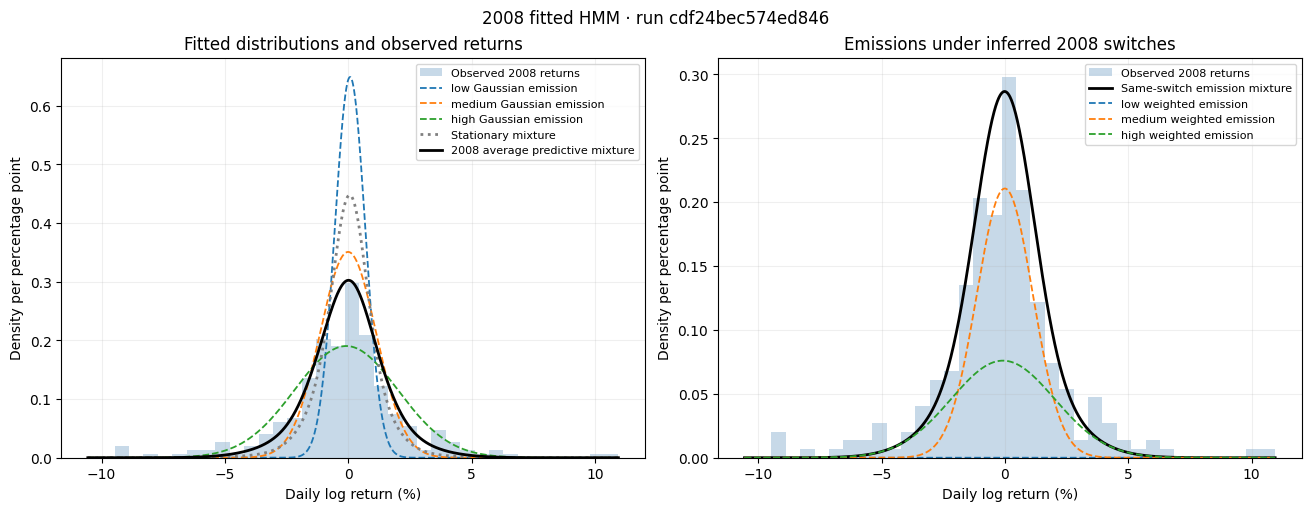

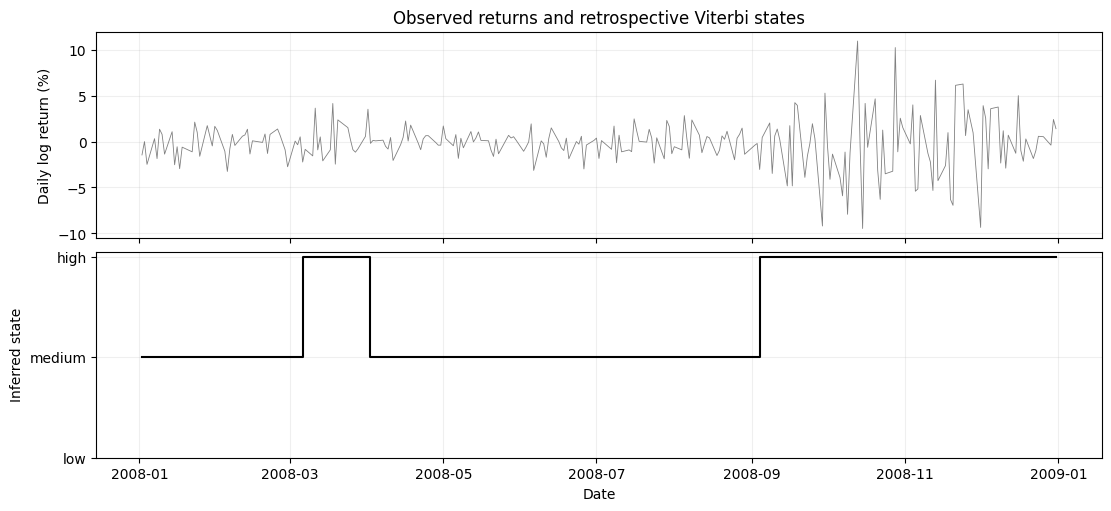

In [16]:
MODEL_YEAR = 2008
parameter_rows = pd.read_json(run_directory / "parameters.json", orient="records")
model_row = parameter_rows.loc[parameter_rows.year == MODEL_YEAR].iloc[0]
year_forecasts = forecasts.loc[forecasts.year == MODEL_YEAR].sort_index()
if year_forecasts.empty:
    raise ValueError(f"No forecasts saved for {MODEL_YEAR}")
year_returns = year_forecasts.r_t.to_numpy(dtype=float)
means = np.asarray(model_row.means, dtype=float)
variances = np.asarray(model_row.variances, dtype=float)
deviations = np.sqrt(variances)
transitions = np.asarray(model_row.transitions, dtype=float)
initial_prior = np.asarray(year_forecasts.predicted_state.iloc[0], dtype=float)
predicted_probabilities = np.stack(year_forecasts.predicted_state.to_numpy())
state_count = len(means)
day_count = len(year_returns)

stationary_system = transitions.T - np.eye(state_count)
stationary_system[-1] = 1
stationary_target = np.zeros(state_count)
stationary_target[-1] = 1
stationary_weights = np.linalg.solve(stationary_system, stationary_target)
average_predictive_weights = predicted_probabilities.mean(axis=0)
emission_log_densities = -0.5 * (
    np.log(2 * np.pi * variances) + (year_returns[:, None] - means) ** 2 / variances
)
viterbi_scores = np.empty((day_count, state_count))
backpointers = np.zeros((day_count, state_count), dtype=int)
viterbi_scores[0] = np.log(np.maximum(initial_prior, np.finfo(float).tiny)) + emission_log_densities[0]
log_transitions = np.log(np.maximum(transitions, np.finfo(float).tiny))
for day_index in range(1, day_count):
    candidates = viterbi_scores[day_index - 1, :, None] + log_transitions
    backpointers[day_index] = candidates.argmax(axis=0)
    viterbi_scores[day_index] = candidates.max(axis=0) + emission_log_densities[day_index]
viterbi_path = np.empty(day_count, dtype=int)
viterbi_path[-1] = viterbi_scores[-1].argmax()
for day_index in range(day_count - 2, -1, -1):
    viterbi_path[day_index] = backpointers[day_index + 1, viterbi_path[day_index + 1]]
path_weights = np.bincount(viterbi_path, minlength=state_count) / day_count
volatility_order = np.argsort(deviations)
volatility_rank = np.empty(state_count, dtype=int)
volatility_rank[volatility_order] = np.arange(state_count)
state_names = ("low", "medium", "high")

grid = np.linspace(min(year_returns.min(), np.min(means - 5 * deviations)),
                   max(year_returns.max(), np.max(means + 5 * deviations)), 1600)
component_densities = np.exp(-0.5 * ((grid[:, None] - means) / deviations) ** 2) / (np.sqrt(2 * np.pi) * deviations)
observed_log_densities = np.log(np.sum(predicted_probabilities * np.exp(emission_log_densities), axis=1))
np.testing.assert_allclose(observed_log_densities, year_forecasts.hmm_log_density.to_numpy(), atol=2e-6)

density_figure, density_axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for density_axis in density_axes:
    density_axis.hist(year_returns * 100, bins=35, density=True, alpha=0.3, color="steelblue", label="Observed 2008 returns")
    density_axis.set(xlabel="Daily log return (%)", ylabel="Density per percentage point")
    density_axis.grid(alpha=0.2)
for state_index in volatility_order:
    label = state_names[volatility_rank[state_index]]
    density_axes[0].plot(grid * 100, component_densities[:, state_index] / 100,
                         linestyle="--", linewidth=1.3, label=f"{label} Gaussian emission")
density_axes[0].plot(grid * 100, component_densities @ stationary_weights / 100,
                     color="gray", linestyle=":", linewidth=2, label="Stationary mixture")
density_axes[0].plot(grid * 100, component_densities @ average_predictive_weights / 100,
                     color="black", linewidth=2, label="2008 average predictive mixture")
density_axes[0].set_title("Fitted distributions and observed returns")
density_axes[0].legend(fontsize=8)
density_axes[1].plot(grid * 100, component_densities @ path_weights / 100,
                     color="black", linewidth=2, label="Same-switch emission mixture")
for state_index in volatility_order:
    label = state_names[volatility_rank[state_index]]
    density_axes[1].plot(grid * 100, path_weights[state_index] * component_densities[:, state_index] / 100,
                         linestyle="--", linewidth=1.3, label=f"{label} weighted emission")
density_axes[1].set_title("Emissions under inferred 2008 switches")
density_axes[1].legend(fontsize=8)
density_figure.suptitle(f"{MODEL_YEAR} fitted HMM · run {run_id}")
density_figure.savefig(run_directory / f"{MODEL_YEAR}_model_implied_distributions.png", dpi=160)

path_figure, (return_axis, state_axis) = plt.subplots(2, 1, figsize=(11, 5), sharex=True, constrained_layout=True)
return_axis.plot(year_forecasts.index, year_returns * 100, color="gray", linewidth=0.6)
return_axis.set(ylabel="Daily log return (%)", title="Observed returns and retrospective Viterbi states")
return_axis.grid(alpha=0.2)
state_axis.step(year_forecasts.index, volatility_rank[viterbi_path], where="post", color="black")
state_axis.set(yticks=range(state_count), yticklabels=state_names, ylabel="Inferred state", xlabel="Date")
state_axis.grid(alpha=0.2)
path_figure.savefig(run_directory / f"{MODEL_YEAR}_inferred_regime_path.png", dpi=160)

emission_rows = []
for state_index in volatility_order:
    assigned = year_returns[viterbi_path == state_index]
    emission_rows.append({
        "state": state_names[volatility_rank[state_index]],
        "assigned_days": len(assigned),
        "fitted_mean_pct": 100 * means[state_index],
        "fitted_sd_pct": 100 * deviations[state_index],
        "assigned_mean_pct": 100 * assigned.mean() if len(assigned) else np.nan,
        "assigned_sd_pct": 100 * assigned.std(ddof=1) if len(assigned) > 1 else np.nan,
        "stationary_weight": stationary_weights[state_index],
        "mean_2008_forecast_weight": average_predictive_weights[state_index],
        "inferred_path_weight": path_weights[state_index],
    })
emission_summary = pd.DataFrame(emission_rows).set_index("state")
print(f"Inferred 2008 switches: {np.count_nonzero(np.diff(viterbi_path))}")
display(emission_summary.round(4))
emission_summary.to_csv(run_directory / f"{MODEL_YEAR}_emission_summary.csv")
plt.show()

### Hold the inferred 2008 switch schedule fixed

Draw 5,000 synthetic years from the fitted Gaussian emission assigned to each date in the Viterbi path above. The transition dates are held fixed, isolating the emission shapes under that retrospective regime schedule. Compare observed mean, volatility, downside quantile, and worst day with the middle 95% of these draws. Because the schedule was inferred from the same observed returns, these are **descriptive reference ranges**, not calibrated hypothesis-test intervals or p-values. The earlier out-of-sample PIT tests remain the formal forecast checks.


In [17]:
SIMULATION_SEED = 2008
SIMULATIONS = 5_000
simulation_rng = np.random.default_rng(SIMULATION_SEED)
replicated_returns = simulation_rng.normal(
    loc=means[viterbi_path], scale=deviations[viterbi_path],
    size=(SIMULATIONS, day_count),
)
observed_statistics = {
    "mean_return_pct": 100 * year_returns.mean(),
    "daily_sd_pct": 100 * year_returns.std(ddof=1),
    "1pct_return_quantile_pct": 100 * np.quantile(year_returns, 0.01),
    "worst_day_pct": 100 * year_returns.min(),
}
replicated_statistics = {
    "mean_return_pct": 100 * replicated_returns.mean(axis=1),
    "daily_sd_pct": 100 * replicated_returns.std(axis=1, ddof=1),
    "1pct_return_quantile_pct": 100 * np.quantile(replicated_returns, 0.01, axis=1),
    "worst_day_pct": 100 * replicated_returns.min(axis=1),
}
for state_index in volatility_order:
    assigned_days = viterbi_path == state_index
    if assigned_days.sum() > 1:
        metric_name = f"{state_names[volatility_rank[state_index]]}_state_sd_pct"
        observed_statistics[metric_name] = 100 * year_returns[assigned_days].std(ddof=1)
        replicated_statistics[metric_name] = 100 * replicated_returns[:, assigned_days].std(axis=1, ddof=1)
reference_rows = []
for metric_name, observed_value in observed_statistics.items():
    lower, upper = np.quantile(replicated_statistics[metric_name], [0.025, 0.975])
    reference_rows.append({
        "metric": metric_name, "observed": observed_value,
        "fixed_switch_lower_95": lower, "fixed_switch_upper_95": upper,
        "outside_reference_range": bool(observed_value < lower or observed_value > upper),
    })
fixed_switch_check = pd.DataFrame(reference_rows).set_index("metric")
display(fixed_switch_check.round(4))
fixed_switch_check.to_csv(run_directory / f"{MODEL_YEAR}_fixed_switch_emission_check.csv")

,observed,fixed_switch_lower_95,fixed_switch_upper_95,outside_reference_range
metric,,,,
mean_return_pct,-0.1921,-0.2343,0.1650,False
daily_sd_pct,2.5837,1.4306,1.7538,True
1pct_return_quantile_pct,-8.5358,-5.0203,-3.1400,True
worst_day_pct,-9.4695,-7.4058,-3.8446,True
medium_state_sd_pct,1.2252,1.0068,1.2664,False
high_state_sd_pct,3.8120,1.8005,2.3794,True
